In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyreadstat
import re

In [2]:
def drop_prefix(df, prefixes):
    cols = [c for c in df.columns if c.startswith(prefixes)]
    df.drop(columns=cols, inplace=True)

In [3]:
def load_and_clean(path, year):

    df, meta = pyreadstat.read_sav(path)

    df["year"] = year # type: ignore

    df.rename(columns=rename_map, inplace=True) # type: ignore

    drop_prefix(df, prefixes) # type: ignore

    missing_pct = df.isna().mean() # type: ignore

    high_missing = missing_pct[missing_pct > 0.95]

    cols_to_drop = high_missing.index.difference(["LondInOut"])

    df.drop(columns=cols_to_drop, inplace=True) # type: ignore

    drop_cols = []

    for col in df.columns: # type: ignore
        if re.search(r'_([D-EG-U])\d+$', col):
            drop_cols.append(col)

    df.drop(columns=drop_cols, inplace=True) # type: ignore

    return df, meta

In [4]:
rename_map = {"nADULT": "nadult",
              "nCHILD": "nchild",
              "VOLANY": "VolAny",
              "FVPor": "FruitVegPor",
              "VOLFRQ_POP": "VolFrqB_Pop"}

In [5]:
prefixes = ("MEMS7GR",
            "FREQUENCYGR",
            "DURATIONGR",
            "ActYr",
            "MUSCLE7_",
            "MUSCLE7GR",
            "DAYS10P60",
            "DAYS10PGR",
            "DAYS10P60GR",
            "ACTYRA",
            "ACTYRB",
            "ACTYRC",
            "LOCAL",
            "MONTHS",
            "WHOWITHA",
            "WHOWITHB",
            "WHOWITHC",
            "WHOWITHD",
            "DUR_",
            "MINS",
            "SET",
            "INOUT",
            "HABITA1A",
            "HABITA1B",
            "HABITA1C",
            "HABITA1AGR",
            "HABITA1BGR",
            "HABITA1CGR",
            "HABITA2A",
            "HABITA2B",
            "HABITA2C",
            "DURATION_",
            "DURATION1PL_",
            "DAYS10P_",
            "wt_final_AB",
            "wt_final_AC",
            "wt_final_B",
            "wt_final_C",
            "wt_final_online",
            "wt_online_time",
            "Overall",
            "Age16plus",
            "Age19plus",
            "group",
            "Quarter",
            "month_gend",
            "month_gendage1660",
            "Month_GR6",
            "Filter_male16",
            "Filter_female16",
            "Filter_Act",
            "Filter_Act_M",
            "Filter_ActAnyVol",
            "Filter_ActNotVol",
            "Filter_AnyVol",
            "Filter_Inact",
            "Filter_Inact_M",
            "Filter_InsAct",
            "Filter_InsAct_M",
            "Filter_NotActAnyVol",
            "Filter_NotActNotVol",
            "Filter_NotVol",
            "Filter_VolMth",
            "Filter_VolOcc",
            "Filter_VolWk",
            "Filter_VolYr",
            "RegACE",
            "CSP",
            "CountyCounc",
            "LA_2009",
            "LA_2015",
            "LA_2019",
            "LA_2020",
            "LA_2021",
            "CCGApr18",
            "STPApr18",
            "ICBJuly22",
            "CoastComm",
            "CoastTown",
            "LDP_combined",
            "LDP_Donc_Combined",
            "Age1640",
            "Age1660",
            "Age2_46",
            "Age2_50",
            "Age2_55",
            "Age2_75",
            "Age3",
            "Age4",
            "Age5",
            "Age5_2",
            "AgeTGC",
            "Nadult_GR3",
            "Child2",
            "ChildAgeU13",
            "ChildNumU13_GR2",
            "MaternityAge2",
            "GendMaternity",
            "GendMaternityAge2",
            "EducStud2",
            "Eth2",
            "EthAge2",
            "EthAge4",
            "gend2_GR2",
            "gend2_GR3",
            "gend2_GR6",
            "GendAge1640",
            "GendAge1660",
            "GendAge2",
            "GendAge2_55",
            "GendAge4",
            "GendAge5",
            "GendAge9",
            "GendAgeTGC",
            "GendDisab2_POP",
            "GendEth2",
            "GendEth7",
            "GendImpair4",
            "GendNSSEC5",
            "GendNSSEC7",
            "GendNSSEC8",
            "GendOrient4",
            "GendRelig7",
            "IMD10_GR2",
            "IMD10_GR3",
            "IMD10_GR5",
            "IMD4",
            "NSSEC7",
            "ONS_Group",
            "ONS_SuperGroup",
            "UrbRur2",
            "UrbRur6",
            "UrbRur6_LA",
            "Equalities_Metric_2024_GR2",
            "BMIG",
            "Valid_BMI_GR4",
            "Valid_BMI_GR2",
            "fruitveg",
            "FruitVegPorG",
            "FruitVegPorG2",
            "VolCnt_GR2",
            "VolDur_GR2",
            "volint1_vol",
            "volint2_vol",
            "volint3_vol",
            "volint4_vol",
            "volint5_vol",
            "volint6_vol",
            "volint7_vol",
            "VolLong_GR3",
            "CULFRQ_1_9_POP2",
            "CULMTH_1_9_POP",
            "Motiva_POP_GR2",
            "motivb_POP_GR2",
            "motivc_POP_GR2",
            "motivd_POP_GR2",
            "motive_POP_GR2",
            "READYAB1_POP_GR2",
            "READYOP1_POP_GR2",
            "motivex2a_GR2",
            "motivex2b_GR2",
            "motivex2c_GR2",
            "motivex2d_GR2",
            "inclus_a_GR2",
            "inclus_b_GR2",
            "inclus_c_GR2",
            "Comm1_GR",
            "Comm2_GR",
            "InDev_GR",
            "InDevtry_GR",
            "WellB_Anxious_GR",
            "WellB_Happy_GR",
            "WellB_Lifesat_GR",
            "WellB_NumberHigh_GR3",
            "WellB_NumberHigh_GR4",
            "WellB_NumberPoor_GR3",
            "WellB_NumberPoor_GR4",
            "WellB_NumberVeryHigh_GR3",
            "WellB_NumberVeryHigh_GR4",
            "WellB_Worthw_GR",
            "MEMS7_CAPPED_SPORTCOUNT_A01",
            "FREQUENCY_CAPPED_SPORTCOUNT_A01",
            "Number_Activities_CAPPED",
            "Number_Activities_Gr2",
            "Number_Activities_Gr3",
            "Number_Activities_Gr5",
            "Number_Activities_150",
            "Number_Activities_150_Gr2",
            "Number_Activities_150_Gr5",
            "FREQUENCY_GR4_SPORTCOUNT_A01",
            "FREQUENCY_GR6_SPORTCOUNT_A01",
            "Mins_Sess_GR2_SPORTCOUNT_A01",
            "Mins_Sess_GR4_SPORTCOUNT_A01",
            "Mins_Sess_GR5min_SPORTCOUNT_A01",
            "Number_Club_Gr2",
            "Number_Club_Gr5",
            "Number_Club_ExcFitness_Gr2",
            "Number_Club_ExcFitness_Gr5",
            "MEMS7_CAPPED_",
            "DAYS10PGR4x_CYCALL_C02",
            "Months_12_NOT4x_CYCALL_C02")

In [6]:
df_22_23, meta_22_23 = load_and_clean('active_lives_survey_nov_22-23_data_year_8_shared_20250103.sav', "2022/23")
df_21_22, meta_21_22 = load_and_clean('active_lives_survey_nov_21-22_data_year_7_shared_20250103.sav', "2021/22")
df_20_21, meta_20_21 = load_and_clean('active_lives_survey_nov_20-21_data_year_6_shared_20250103.sav', "2020/21")
df_19_20, meta_19_20 = load_and_clean('active_lives_survey_nov_19-20_data_year_5_shared_20250103.sav', "2019/20")
df_18_19, meta_18_19 = load_and_clean('active_lives_survey_nov_18-19_data_year_4_shared_20250103.sav', "2018/19")
df_17_18, meta_17_18 = load_and_clean('active_lives_survey_nov_17-18_data_year_3_shared_20250103.sav', "2017/18")
df_16_17, meta_16_17 = load_and_clean('active_lives_survey_nov_16-17_data_year_2_shared_20250106.sav', "2016/17")
df_15_16, meta_15_16 = load_and_clean('active_lives_survey_nov_15-16_data_year_1_shared_20250106.sav', "2015/16")

In [7]:
active_lives_dictionary = pd.DataFrame({"variable": meta_22_23.column_names, "label": meta_22_23.column_labels})

active_lives_dictionary.to_excel("active_lives_dictionary.xlsx", index=False)

In [8]:
dfs = [df_15_16, df_16_17, df_17_18, df_18_19, df_19_20, df_20_21, df_21_22, df_22_23]

for df in dfs:
    print(df.shape)  # type: ignore

(198911, 231)
(196635, 380)
(179747, 449)
(181535, 466)
(177735, 448)
(177273, 451)
(177551, 298)
(172968, 289)


In [9]:
common_cols = set(dfs[0].columns) # type: ignore

for df in dfs[1:]:
    common_cols &= set(df.columns) # type: ignore

print(len(common_cols))

130


In [10]:
reference = set(df_22_23.columns) # type: ignore

for name, df in zip(["15/16", "16/17","17/18","18/19","19/20","20/21","21/22","22/23"], dfs):
    
    missing = reference - set(df.columns) # type: ignore

    print(name, len(missing))

15/16 158
16/17 40
17/18 30
18/19 28
19/20 26
20/21 15
21/22 13
22/23 0


In [11]:
lost_from_2022 = set(df_22_23.columns) - common_cols # type: ignore

print(len(lost_from_2022))

for col in sorted(lost_from_2022):
    print(col)

159
ACT7GR_ALL
Age17
CLUB_ADVWATERSPORT_C07
CLUB_BASESOFTBALL_F13
CLUB_BASKETBALL_F07
CLUB_COMBATTARGET_C09
CLUB_CRICKET_F02
CLUB_CYCALL_C02
CLUB_CYCLEISSPORT_B03
CLUB_DANCEALL_C04
CLUB_DANCEARTACE
CLUB_DANCEART_B05
CLUB_DODGEBALL_F12
CLUB_FITNESS_B06
CLUB_FOOTBALL_F01
CLUB_GOALBALL_F15
CLUB_GYMTRAMPCHEER_C13
CLUB_HANDBALL_F16
CLUB_HOCKEY_F09
CLUB_INFORMAL_C15
CLUB_LACROSSE_F14
CLUB_LEISURE_C08
CLUB_NETBALL_F06
CLUB_RACKETSPORT_C06
CLUB_ROLLER_C14
CLUB_ROUNDERS_F11
CLUB_RUGBYLEAGUE_F04
CLUB_RUGBYUNION_F03
CLUB_RUNATHMULTI_C11
CLUB_SPORTCOUNT_A01
CLUB_SPORTFUND_A02
CLUB_SPORTPRE2016_A03
CLUB_SPORTTRAD_B07
CLUB_TEAMSPORT_C05
CLUB_VOLLEYBALL_F10
CLUB_WALKALL_C01
CLUB_WALKLEISURE_B01
CLUB_WHEELCHBASKETBALL_F08
CLUB_WHEELCHRUGBY_F05
CLUB_WINTER_C10
Club_ExcFitness
FREQUENCY_CYCALL_C02
FREQUENCY_CYCLEISSPORT_B03
FREQUENCY_FITNESS_B06
FREQUENCY_INFORMAL_C15
HHLiv12
HHLiv23
HHLiv5
LondInOut_old
MEMS7_CYCALL_C02
MEMS7_CYCLEISSPORT_B03
MEMS7_FITNESS_B06
MEMS7_INFORMAL_C15
MEMS7_INOUT_BUILT_FITNE

In [12]:
availability = []

for var in lost_from_2022:

    count = sum(var in df.columns for df in dfs[1:])  # type: ignore

    availability.append({
        "variable": var,
        "n_years": count})

availability_df = (
    pd.DataFrame(availability)
    .sort_values("n_years", ascending=False))

print(availability_df)

                     variable  n_years
2    MEMS7_OUT_SPORTCOUNT_A01        7
4                     HHLiv12        7
3             CLUB_ROLLER_C14        7
5                       happy        7
6       CLUB_SPORTPRE2016_A03        7
..                        ...      ...
107                 limfreti4        1
124                 limfreti8        1
121                  inclus_b        1
104                 limfreti6        1
157                 limfreti3        1

[159 rows x 2 columns]


In [13]:
latest_cols = list(df_22_23.columns) # type: ignore

var_counts = Counter()

for df in dfs:
    var_counts.update(df.columns) # type: ignore

keep_cols = [col for col in latest_cols if var_counts[col] >= 4]

In [14]:
dfs_aligned = []

for df in dfs:

    df_copy = df[[c for c in df.columns if c in keep_cols]] # type: ignore

    missing_cols = set(keep_cols) - set(df_copy.columns)

    for col in missing_cols:
        df_copy[col] = np.nan

    df_copy = df_copy[keep_cols]

    dfs_aligned.append(df_copy)

C:\Users\Matt_\AppData\Local\Temp\ipykernel_19044\2763078233.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[col] = np.nan
C:\Users\Matt_\AppData\Local\Temp\ipykernel_19044\2763078233.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[col] = np.nan
C:\Users\Matt_\AppData\Local\Temp\ipykernel_19044\2763078233.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

In [15]:
overall_df = pd.concat(dfs_aligned, axis=0, ignore_index=True)

print(overall_df.shape)

(1462355, 264)


In [16]:
overall_df = overall_df[overall_df['LondInOut'].notna()]

# overall_df = pyreadstat.set_value_labels(overall_df, meta_22_23)

In [17]:
# overall_df['LA_2023'] = overall_df['LA_2023'].astype(str)
# overall_df['LA_Code'] = overall_df['LA_2023'].str.split(' ', n=1).str[0]
# overall_df['LA_Name'] = overall_df['LA_2023'].str.split(' ', n=1).str[1]
# overall_df.drop(columns=['LA_2023'], inplace=True)

In [18]:
overall_df.to_csv("2016_to_2023_full_preprocessed_data_set.csv.gz", index=False, compression="gzip")
overall_df.to_csv("2016_to_2023_full_preprocessed_data_set.csv", index=False)

In [19]:
missing_summary = (overall_df.isna().mean().sort_values(ascending=False).reset_index())

missing_summary.columns = ["variable", "missing_pct"]

print(missing_summary.head(50))

                                       variable  missing_pct
0                                       VolLong     0.949224
1                                        VolDur     0.948636
2                                    motive_POP     0.948454
3                                      indevtry     0.744363
4            MEMS7_INOUT_SPECIALIST_FITNESS_B06     0.739914
5            MEMS7_INOUT_LEISURE_SPORTCOUNT_A01     0.739914
6              MEMS7_INOUT_BUILT_SPORTCOUNT_A01     0.739914
7         MEMS7_INOUT_SPECIALIST_SPORTCOUNT_A01     0.739914
8              MEMS7_INOUT_OTHER_SPORTCOUNT_A01     0.739914
9           MEMS7_OUT_BUILT_LEISURE_FITNESS_B06     0.739914
10              MEMS7_INOUT_LEISURE_FITNESS_B06     0.739914
11                MEMS7_INOUT_BUILT_FITNESS_B06     0.739914
12                MEMS7_INOUT_OTHER_FITNESS_B06     0.739914
13       MEMS7_OUT_BUILT_SPECIALIST_FITNESS_B06     0.739914
14                                        comm1     0.702630
15                      

In [20]:
target = "MEMS7_ALL"

features = ["Age17",
            "Gend3",
            "Eth7",
            "Disab3",
            "preg_pop",
            "nadult",
            "nchild",
            "Educ6",
            "IMD10",
            "NSSEC8",
            "WorkStat10",
            "HHLiv12",
            "health",
            "VolAny",
            "Motiva_POP",
            "motivb_POP",
            "motivc_POP",
            "motivd_POP",
            "anxious",
            "happy",
            "lifesat",
            "worthw",
            "comm1",
            "lone",
            "CULFRQ_1_9_POP"]

rf_df = overall_df[features + [target]].copy()

X = rf_df[features]
y = rf_df[target]

In [21]:
for col in X.columns:  # type: ignore

    if X[col].dtype == "object": X[col] = LabelEncoder().fit_transform(X[col].astype(str))

imputer = SimpleImputer(strategy="most_frequent")

X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)

rf.fit(X, y);

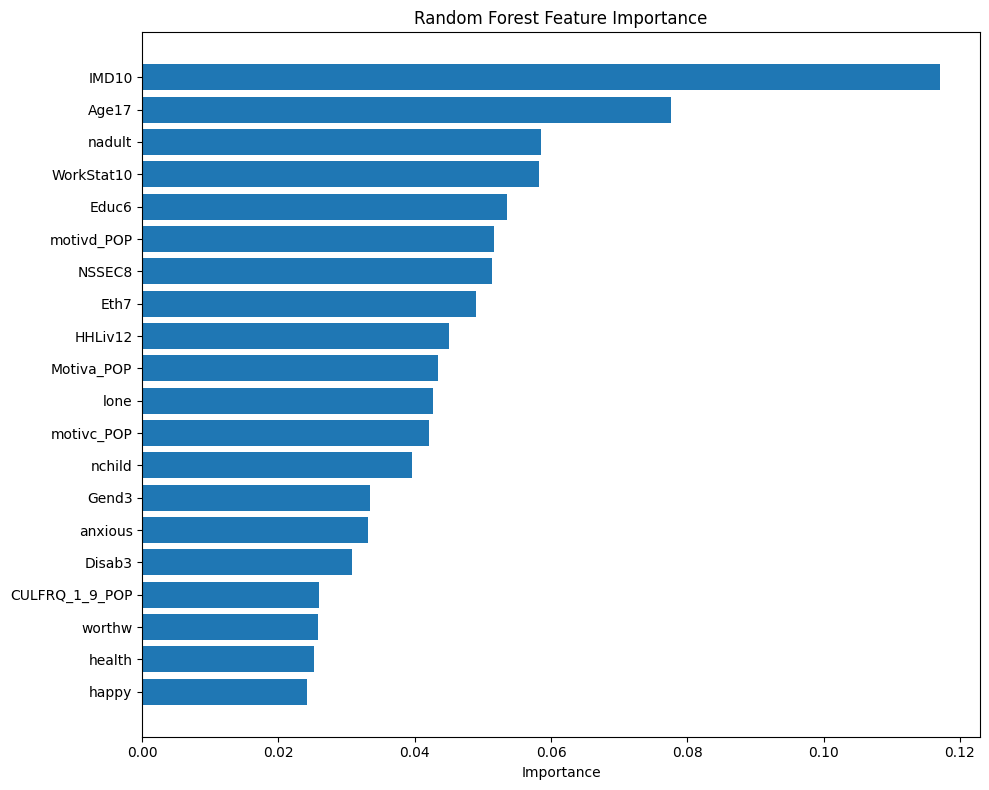

In [22]:
importance_df = pd.DataFrame({"feature": X.columns, "importance": rf.feature_importances_})

importance_df = (importance_df.sort_values("importance", ascending=False))

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20["feature"][::-1],
         top20["importance"][::-1])

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()